In [123]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Test noise reduction algorithm and view steps of algorithm

In [124]:
import IPython
import matplotlib.pyplot as plt
import numpy as np
import os
import shutil
import soundfile as sf
import subprocess
import tempfile
from pathlib import Path
%matplotlib inline


def find_repo_root():
    here = Path.cwd().resolve()
    for candidate in (here, *here.parents):
        if (candidate / "go.mod").exists() and (candidate / "cmd" / "noisereduce" / "main.go").exists():
            return candidate
    raise FileNotFoundError("Run this notebook from the noisereduce repository or its notebooks directory")


REPO_ROOT = find_repo_root()
ASSET_DIR = REPO_ROOT / "assets"

if shutil.which("go") is None:
    raise RuntimeError("Go is required to run the local noisereduce CLI")


def noisereduce_cli():
    bin_name = "noisereduce.exe" if os.name == "nt" else "noisereduce"
    bin_path = REPO_ROOT / "bin" / bin_name
    sources = list(REPO_ROOT.glob("*.go")) + list((REPO_ROOT / "cmd" / "noisereduce").glob("*.go"))
    needs_build = not bin_path.exists() or any(src.stat().st_mtime > bin_path.stat().st_mtime for src in sources)
    if needs_build:
        bin_path.parent.mkdir(exist_ok=True)
        result = subprocess.run(
            ["go", "build", "-o", str(bin_path), "./cmd/noisereduce"],
            cwd=REPO_ROOT,
            capture_output=True,
            text=True,
        )
        if result.returncode != 0:
            raise RuntimeError(result.stderr or result.stdout)
    return str(bin_path)


# from https://stackoverflow.com/questions/33933842/how-to-generate-noise-in-frequency-range-with-numpy
def fftnoise(f):
    f = np.array(f, dtype="complex")
    Np = (len(f) - 1) // 2
    phases = np.random.rand(Np) * 2 * np.pi
    phases = np.cos(phases) + 1j * np.sin(phases)
    f[1 : Np + 1] *= phases
    f[-1 : -1 - Np : -1] = np.conj(f[1 : Np + 1])
    return np.fft.ifft(f).real


def band_limited_noise(min_freq, max_freq, samples=1024, samplerate=1):
    freqs = np.abs(np.fft.fftfreq(samples, 1 / samplerate))
    f = np.zeros(samples)
    f[np.logical_and(freqs >= min_freq, freqs <= max_freq)] = 1
    return fftnoise(f)


def _sf_data(y):
    arr = np.asarray(y, dtype=np.float32)
    if arr.ndim == 1:
        return arr
    if arr.ndim == 2:
        return arr.T
    raise ValueError("audio must be shaped [frames] or [channels, frames]")


def _restore_shape(y_out, template):
    template = np.asarray(template)
    out = np.asarray(y_out, dtype=np.float64)
    if template.ndim == 2:
        if out.ndim == 1:
            out = out[:, np.newaxis]
        return out.T
    return out


def reduce_noise_go(
    y,
    sr,
    y_noise=None,
    stationary=False,
    prop_decrease=1.0,
    n_std_thresh_stationary=1.5,
    n_fft=1024,
    win_length=0,
    hop_length=0,
    time_constant_s=2.0,
    chunk_size=600000,
    padding=30000,
    n_jobs=0,
):
    with tempfile.TemporaryDirectory(prefix="nr-", dir=REPO_ROOT) as tmp:
        tmp = Path(tmp)
        in_path = tmp / "input.wav"
        out_path = tmp / "clean.wav"
        sf.write(in_path, _sf_data(y), sr)

        cmd = [
            noisereduce_cli(),
            "-in", str(in_path),
            "-out", str(out_path),
            "-prop-decrease", str(prop_decrease),
            "-n-fft", str(n_fft),
            "-win-length", str(win_length),
            "-hop-length", str(hop_length),
            "-time-constant", str(time_constant_s),
            "-n-std-thresh", str(n_std_thresh_stationary),
            "-chunk-size", str(chunk_size),
            "-padding", str(padding),
            "-jobs", str(n_jobs),
        ]
        if stationary or y_noise is not None:
            cmd.append("-stationary")
        if y_noise is not None:
            noise_path = tmp / "noise.wav"
            sf.write(noise_path, _sf_data(y_noise), sr)
            cmd.extend(["-noise", str(noise_path)])

        result = subprocess.run(cmd, cwd=REPO_ROOT, capture_output=True, text=True)
        if result.returncode != 0:
            raise RuntimeError(result.stderr or result.stdout)

        clean, out_sr = sf.read(out_path, always_2d=False)
        if out_sr != sr:
            raise RuntimeError(f"unexpected output sample rate {out_sr}, expected {sr}")
        return _restore_shape(clean, y)


### Load data

In [125]:
data, rate = sf.read(ASSET_DIR / "fish.wav")
data = np.asarray(data, dtype=np.float64)


In [126]:
IPython.display.Audio(data=data, rate=rate)

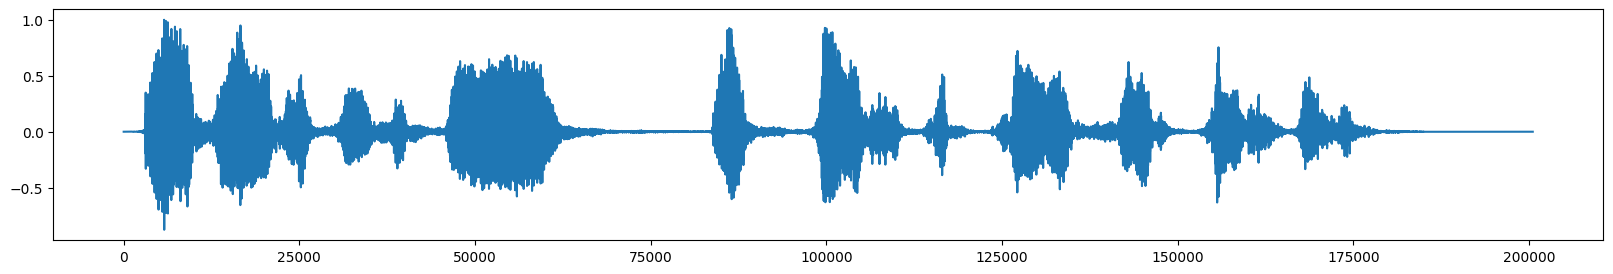

In [127]:
fig, ax = plt.subplots(figsize=(20,3))
ax.plot(data)

### add noise

In [128]:
noise_len = 2 # seconds
noise = band_limited_noise(min_freq=2000, max_freq=12000, samples=len(data), samplerate=rate) * 10
noise_clip = noise[:rate * noise_len]
audio_clip_band_limited = data + noise


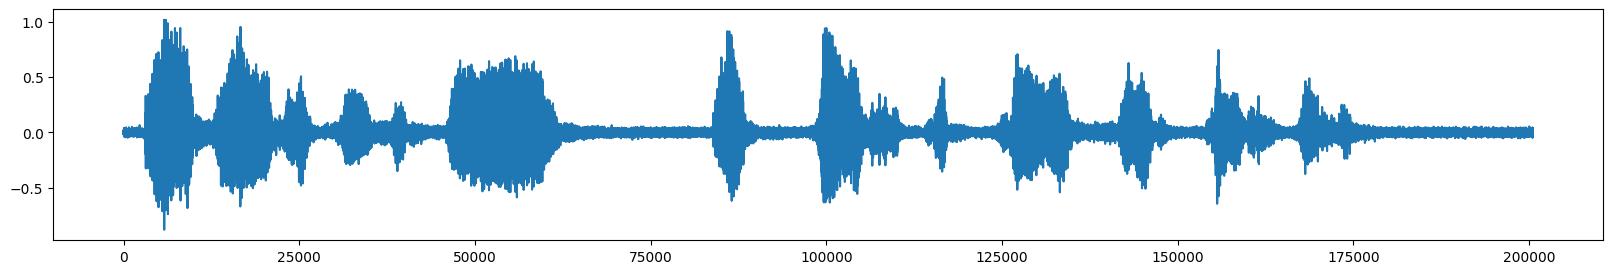

In [129]:
fig, ax = plt.subplots(figsize=(20,3))
ax.plot(audio_clip_band_limited)

In [130]:
IPython.display.Audio(data=audio_clip_band_limited, rate=rate)

### Stationary remove noise

In [131]:
reduced_noise = reduce_noise_go(
    audio_clip_band_limited,
    rate,
    n_std_thresh_stationary=1.5,
    stationary=True,
)


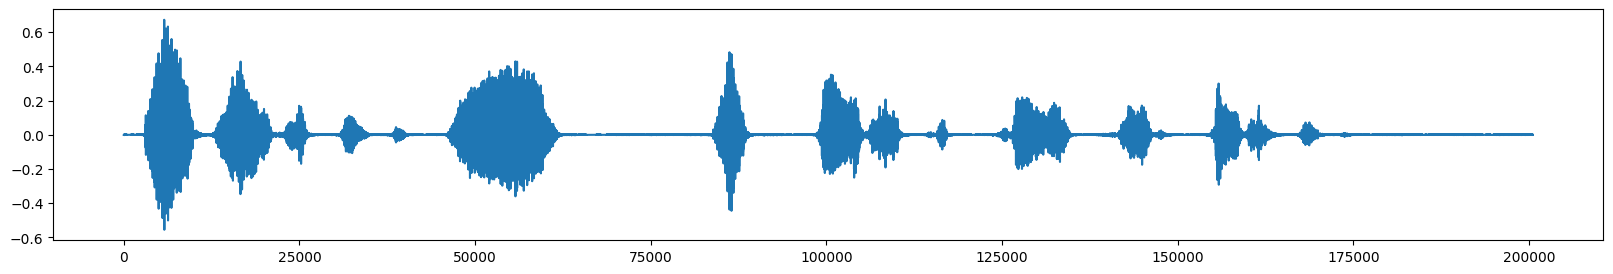

In [132]:
fig, ax = plt.subplots(figsize=(20,3))
ax.plot(reduced_noise)

In [133]:
IPython.display.Audio(data=reduced_noise, rate=rate)

### Non-stationary noise reduction

In [134]:
reduced_noise = reduce_noise_go(
    audio_clip_band_limited,
    rate,
    stationary=False,
)


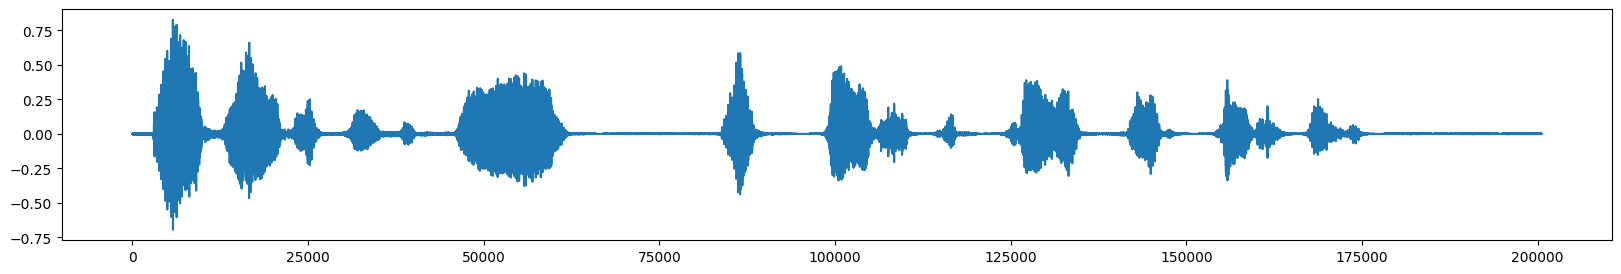

In [135]:
fig, ax = plt.subplots(figsize=(20,3))
ax.plot(reduced_noise)

## A more difficult example 

In [136]:
noise_data, noise_rate = sf.read(ASSET_DIR / "cafe_short.wav")
noise_data = np.asarray(noise_data, dtype=np.float64)


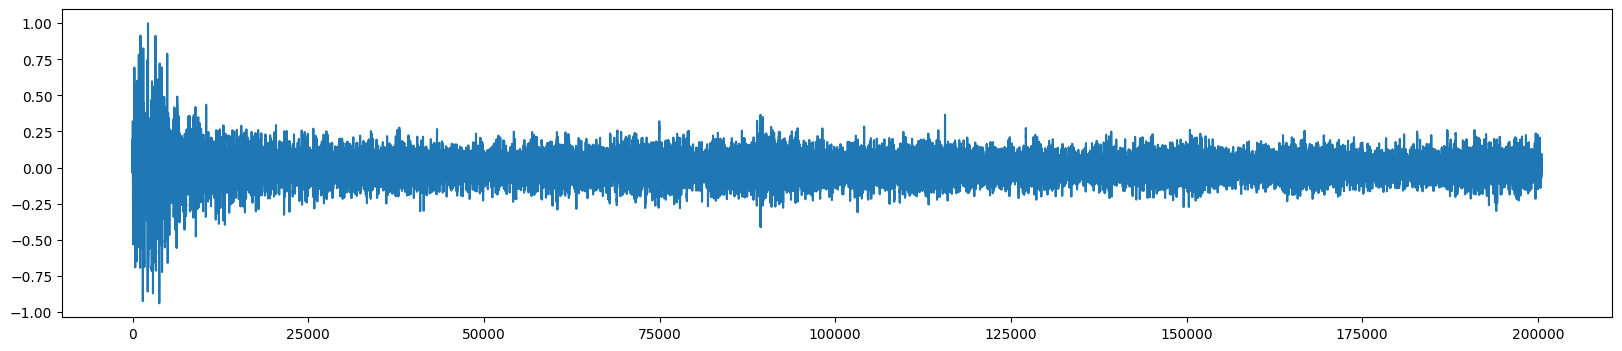

In [137]:
fig, ax = plt.subplots(figsize=(20,4))
ax.plot(noise_data)

In [138]:
IPython.display.Audio(data=noise_data, rate=noise_rate)

### add noise to data

In [139]:
snr = 2 # signal to noise ratio
noise_clip = noise_data/snr
audio_clip_cafe = data + noise_clip

### plot noisy data

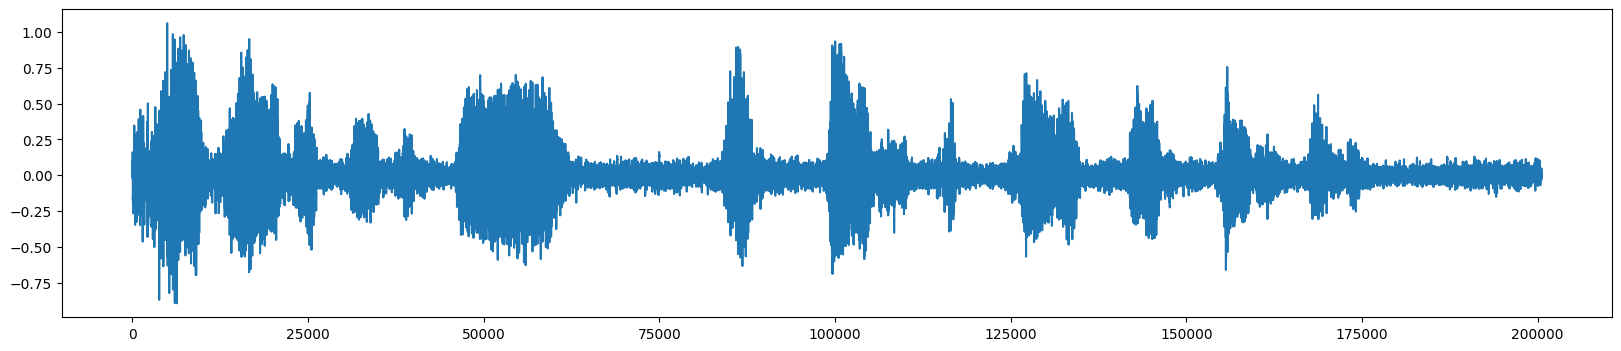

In [140]:
fig, ax = plt.subplots(figsize=(20,4))
ax.plot(audio_clip_cafe)
IPython.display.Audio(data=audio_clip_cafe, rate=noise_rate)

### Stationary remove noise

In [141]:
reduced_noise = reduce_noise_go(
    audio_clip_cafe,
    rate,
    y_noise=noise_clip,
    n_std_thresh_stationary=1.5,
    stationary=True,
)


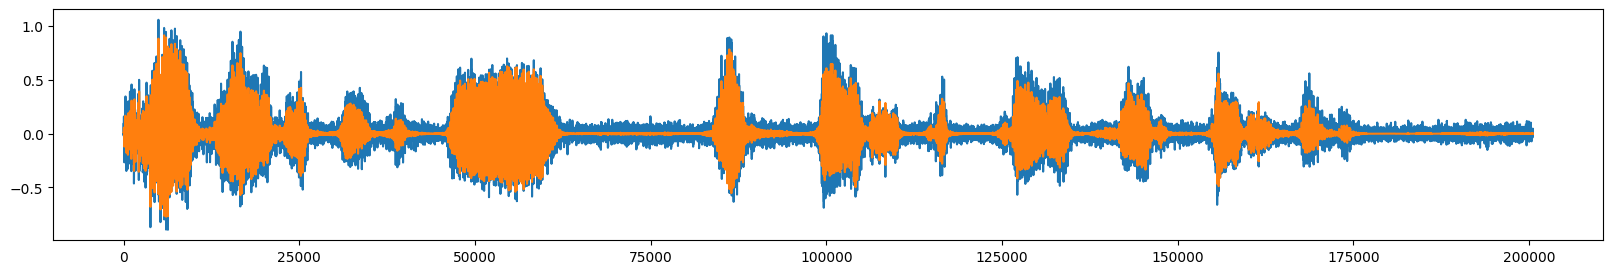

In [142]:
fig, ax = plt.subplots(figsize=(20,3))
ax.plot(audio_clip_cafe)
ax.plot(reduced_noise)

In [143]:
IPython.display.Audio(data=reduced_noise, rate=rate)

### Non-stationary noise reduction

In [144]:
reduced_noise = reduce_noise_go(
    audio_clip_cafe,
    rate,
    stationary=False,
)


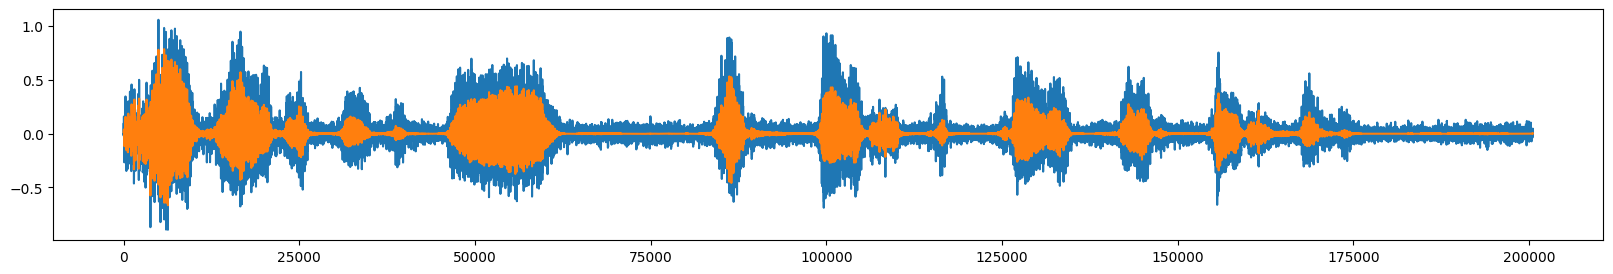

In [145]:
fig, ax = plt.subplots(figsize=(20,3))
ax.plot(audio_clip_cafe)
ax.plot(reduced_noise, alpha = 1)
IPython.display.Audio(data=reduced_noise, rate=rate)

In [146]:
IPython.display.Audio(data=reduced_noise, rate=rate)

### ensure that noise reduction does not cause distortion when prop_decrease == 0

In [147]:
noise_reduced = reduce_noise_go(data, rate, prop_decrease=0, stationary=False)


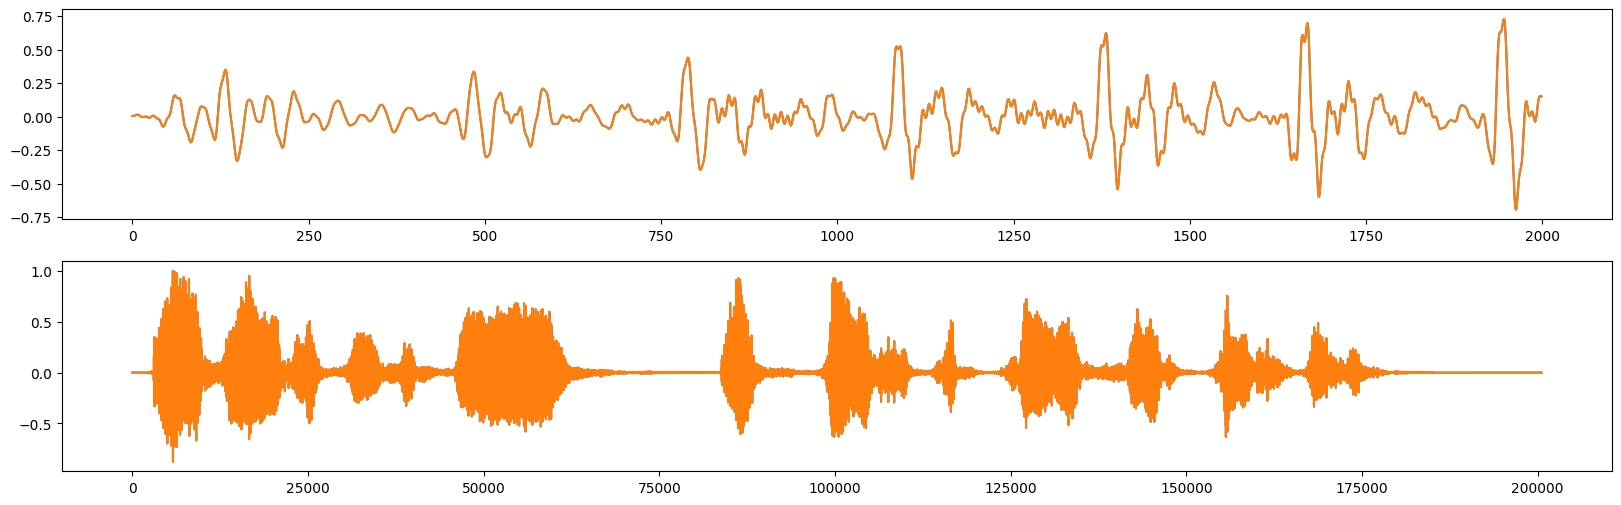

In [148]:
fig, axs = plt.subplots(nrows=2, figsize=(20,6))
axs[0].plot(data[3000:5000])
axs[0].plot(noise_reduced[3000:5000])
axs[1].plot(data)
axs[1].plot(noise_reduced)

In [149]:
noise_reduced = reduce_noise_go(data, rate, prop_decrease=0, stationary=True)


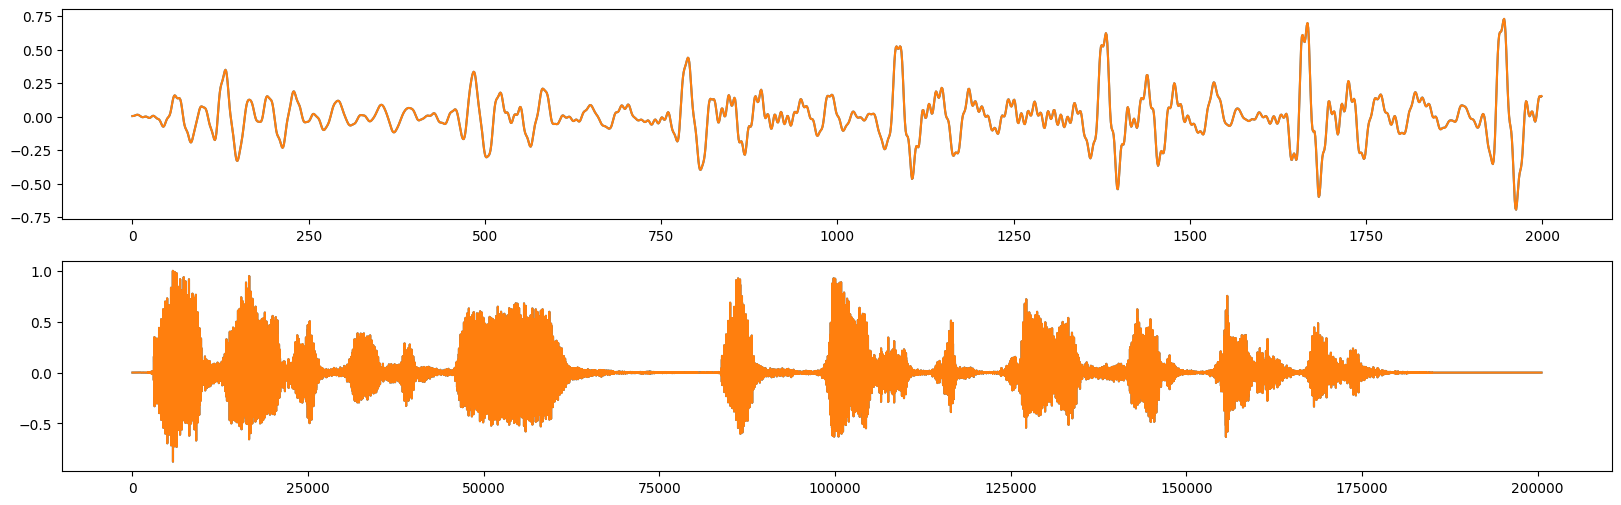

In [150]:
fig, axs = plt.subplots(nrows=2, figsize=(20,6))
axs[0].plot(data[3000:5000])
axs[0].plot(noise_reduced[3000:5000])
axs[1].plot(data)
axs[1].plot(noise_reduced)

### Reduce noise over batches in parallel on long signal

In [151]:
long_data = np.tile(data, 10)
len(long_data)/rate

45.47437641723356

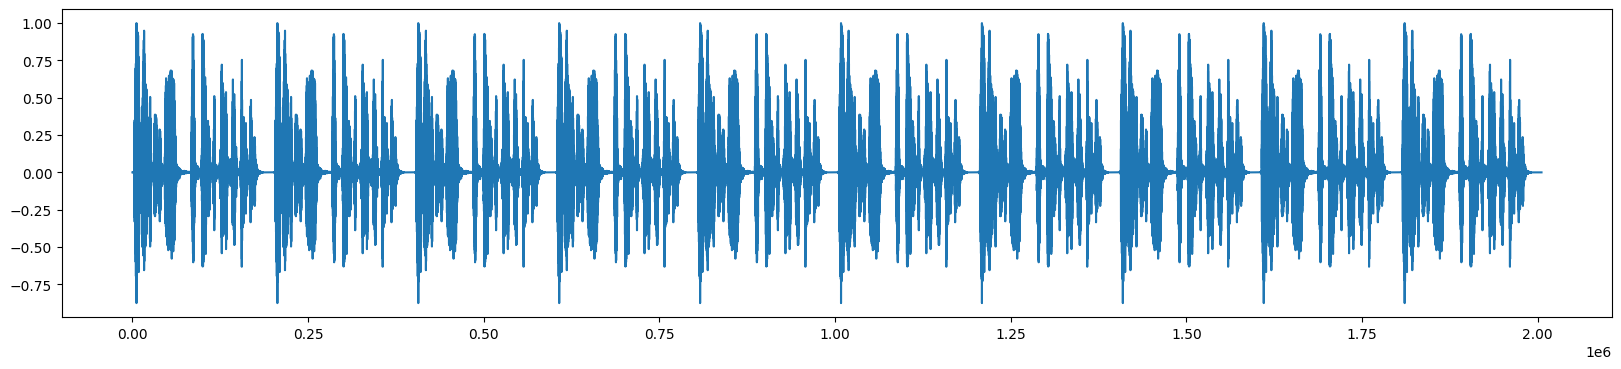

In [152]:
fig, ax = plt.subplots(figsize=(20,4))
ax.plot(long_data)

In [153]:
noise = band_limited_noise(min_freq=2000, max_freq = 12000, samples=len(long_data), samplerate=rate)*10
audio_clip_band_limited = long_data+noise

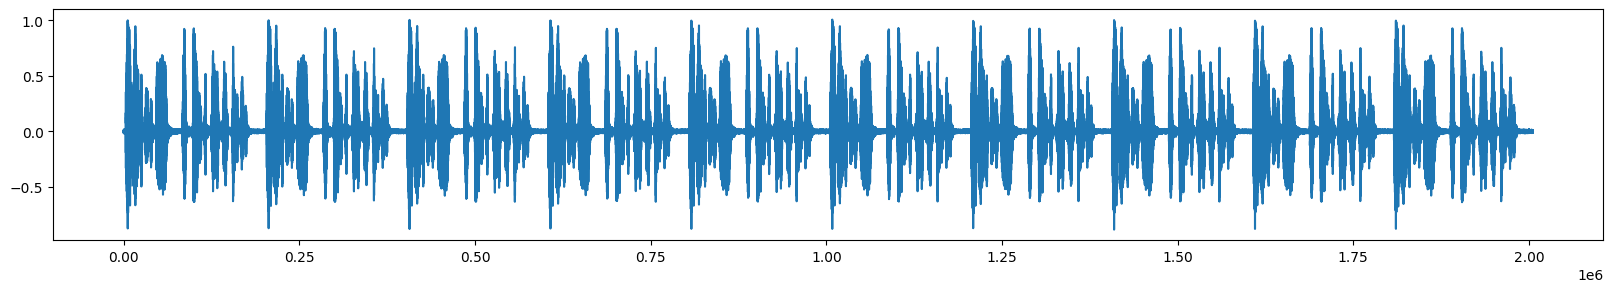

In [154]:
fig, ax = plt.subplots(figsize=(20,3))
ax.plot(audio_clip_band_limited)

In [155]:
reduced_noise = reduce_noise_go(
    audio_clip_band_limited,
    rate,
    stationary=False,
    n_jobs=2,
)


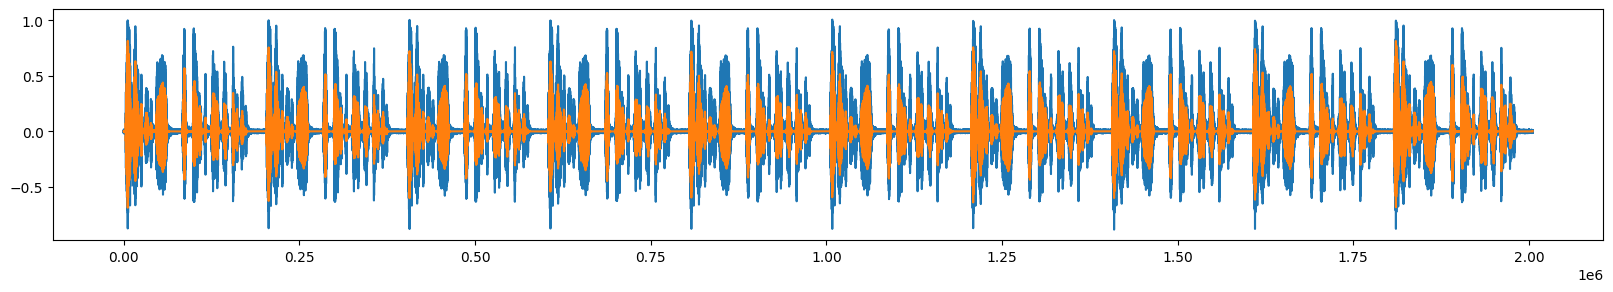

In [156]:
fig, ax = plt.subplots(figsize=(20,3))
ax.plot(audio_clip_band_limited)
ax.plot(reduced_noise)

In [157]:
reduced_noise = reduce_noise_go(
    audio_clip_band_limited,
    rate,
    stationary=True,
    n_jobs=2,
)


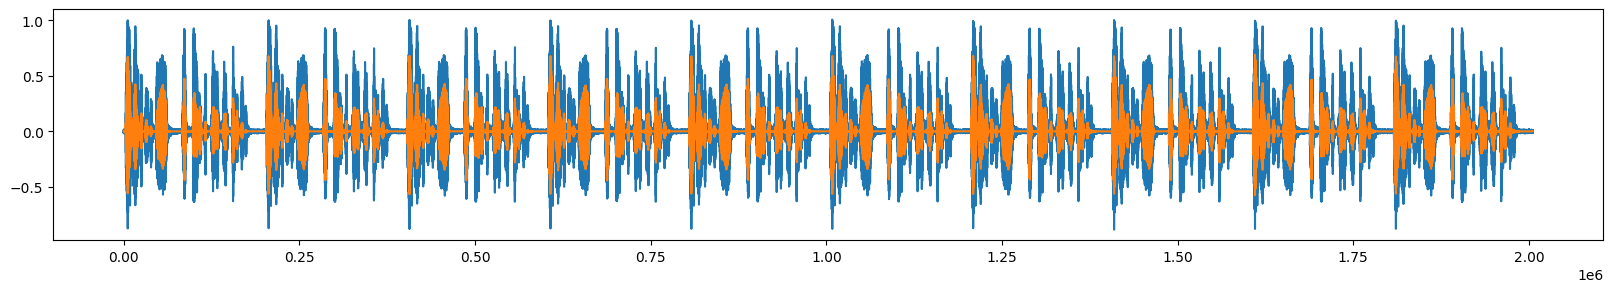

In [158]:
fig, ax = plt.subplots(figsize=(20,3))
ax.plot(audio_clip_band_limited)
ax.plot(reduced_noise)

### Reduce noise on only a subset of a long clip

In [159]:
subset_start, subset_end = 10000, 20000


In [160]:
stationary_full = reduce_noise_go(data, rate, stationary=True)


In [161]:
subset_noise_reduce = stationary_full[subset_start:subset_end]


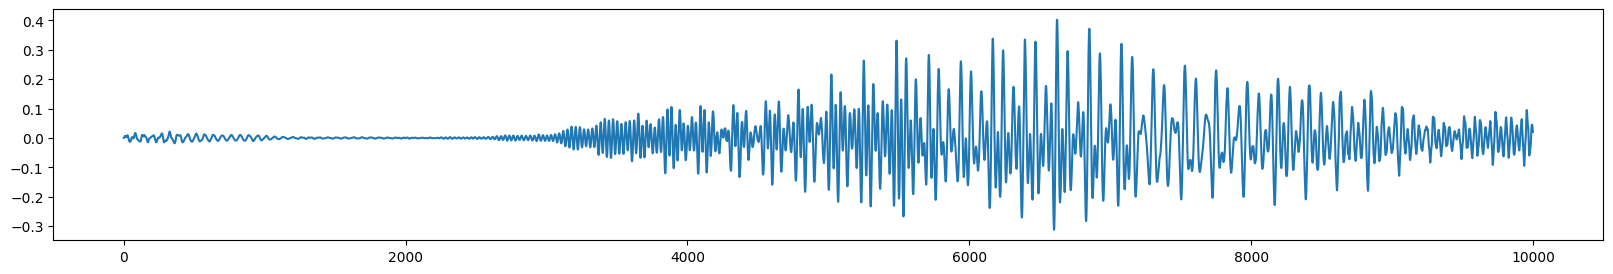

In [162]:
fig, ax = plt.subplots(figsize=(20,3))
ax.plot(subset_noise_reduce)

## Multichannel noise

In [163]:
audio_clip_cafe_2_channel = np.vstack([audio_clip_cafe, audio_clip_cafe])
audio_clip_cafe_2_channel.shape

(2, 200542)

In [164]:
reduced_noise = reduce_noise_go(
    audio_clip_cafe_2_channel,
    rate,
    n_std_thresh_stationary=1.5,
    stationary=True,
)


In [165]:
reduced_noise.shape

(2, 200542)

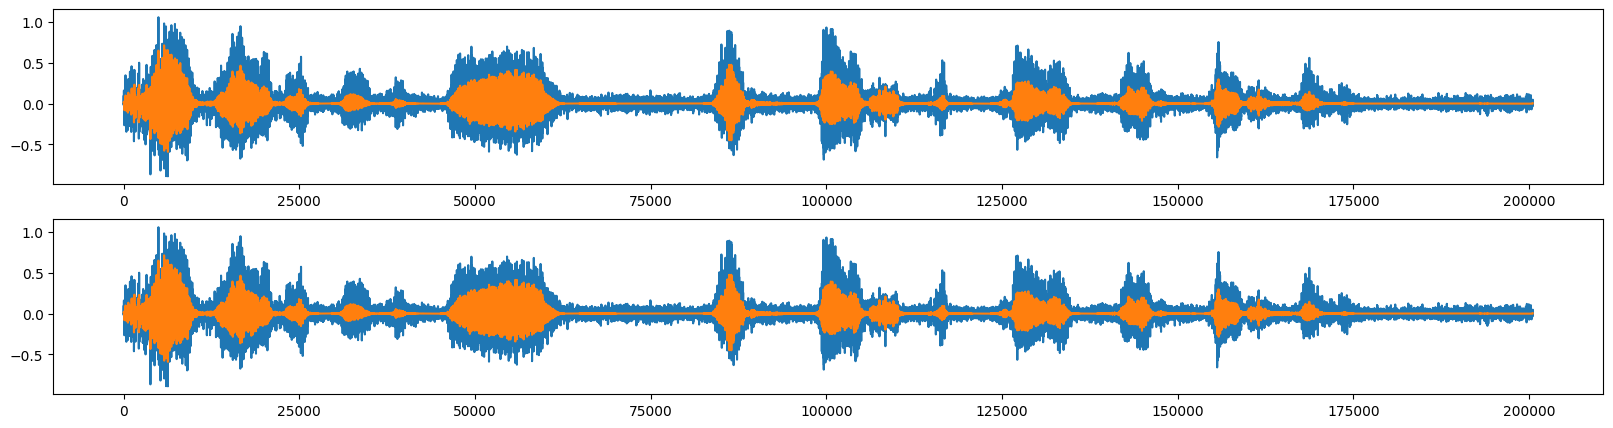

In [166]:
fig, axs = plt.subplots(nrows= 2, figsize=(20,5))
axs[0].plot(audio_clip_cafe_2_channel[0])
axs[1].plot(audio_clip_cafe_2_channel[1])

axs[0].plot(reduced_noise[0])
axs[1].plot(reduced_noise[1])

In [167]:
IPython.display.Audio(data=reduced_noise, rate=rate)

In [168]:
reduced_noise = reduce_noise_go(
    audio_clip_cafe,
    rate,
    stationary=False,
)


In [169]:
reduced_noise.shape

(200542,)

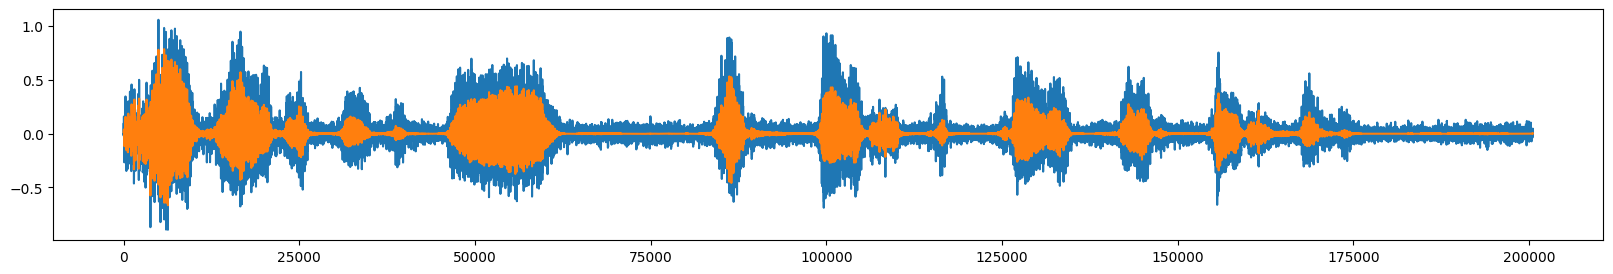

In [170]:
fig, ax = plt.subplots(figsize=(20,3))
ax.plot(audio_clip_cafe)
ax.plot(reduced_noise, alpha = 1)
IPython.display.Audio(data=reduced_noise, rate=rate)